# Tutorial 6h: Needle Synthesis for Thin Film Design

This tutorial demonstrates the **needle synthesis** algorithm for discovering optimal thin film stack configurations, using real dispersive materials from the optiland catalog on **N-BK7** glass.

Two design examples of increasing complexity:
- **Part 1 — Broadband AR coating**: R < 1% across 420–680 nm, starting from a single MgF2 layer
- **Part 2 — Dichroic beamsplitter**: R > 95% for 420–540 nm, T > 95% for 560–680 nm, starting from a (HL)³ quarter-wave stack

**Reference**: Tikhonravov & Trubetskov, *Development of the needle optimization technique and new features of OptiLayer design software*, SPIE Vol. 2253, 1994.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optiland.materials import Material, IdealMaterial
from optiland.thin_film import ThinFilmStack, SpectralAnalyzer
from optiland.thin_film.optimization import NeedleSynthesis
from optiland.thin_film.optimization.operand.thin_film import ThinFilmOperand

# Part 1: Broadband AR Coating (R < 1%)

## 1. Define materials and starting design

We use **real dispersive materials** from the optiland catalog:

| Material | Role | n @ 550 nm | Reference |
|----------|------|-----------|-----------|
| N-BK7 | Substrate | 1.519 | Schott |
| SiO2 | Low-index layer | 1.460 | Malitson |
| TiO2 | High-index layer | 2.648 | Devore |
| MgF2 | Very low-index layer | 1.379 | Dodge |
| Al2O3 | Mid-index layer | 1.770 | Malitson |

We start from a single MgF2 quarter-wave layer — the simplest possible AR coating. A single low-index layer on N-BK7 gives roughly 1.4% reflectance, which already violates our < 1% spec at the band edges.

In [2]:
# Incident medium
air = IdealMaterial(n=1.0)

# Substrate
nbk7 = Material("N-BK7")

# Candidate coating materials (dispersive)
sio2 = Material("SiO2", reference="Malitson")
tio2 = Material("TiO2", reference="Devore-o")
mgf2 = Material("MgF2", reference="Dodge-o")
al2o3 = Material("Al2O3", reference="Malitson")

# Print refractive indices at 550 nm
for name, mat in [("N-BK7", nbk7), ("SiO2", sio2), ("TiO2", tio2),
                   ("MgF2", mgf2), ("Al2O3", al2o3)]:
    print(f"{name:6s}  n(550nm) = {np.asarray(mat.n(0.55)).item():.4f}")

# Starting design: single MgF2 layer
stack = ThinFilmStack(incident_material=air, substrate_material=nbk7)
stack.add_layer_nm(mgf2, 100.0, name="MgF2")
print("\nStarting design:")
print(stack)

N-BK7   n(550nm) = 1.5185
SiO2    n(550nm) = 1.4599
TiO2    n(550nm) = 2.6479
MgF2    n(550nm) = 1.3785
Al2O3   n(550nm) = 1.7704

Starting design:
ThinFilmStack Summary
---------------------
Incident:  IdealMaterial
Substrate: N-BK7
Layers:
  1. MgF2 (100.0 nm)
---------------------
Total Thickness: 100.0 nm


## 2. Starting performance

The single MgF2 layer gives ~1.4% average reflectance. The 1% spec line (dashed red) shows the design fails across most of the band.

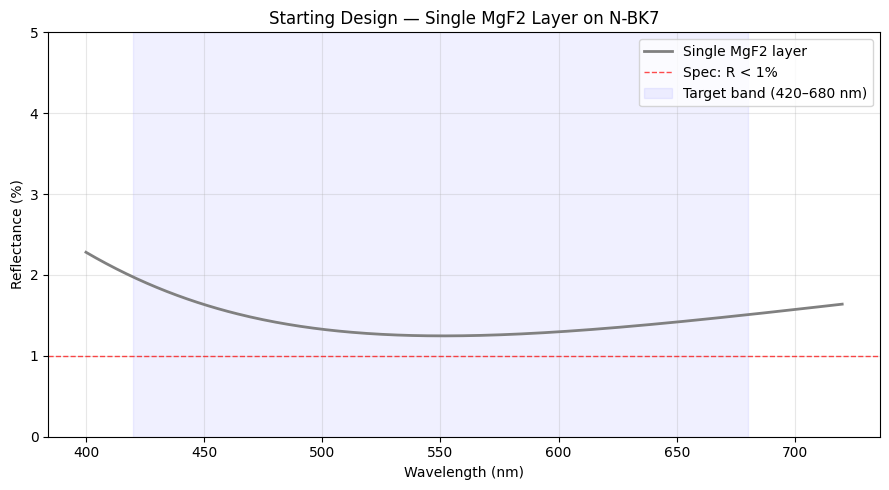

In [3]:
wl_plot = np.linspace(400, 720, 300)
R_start = np.array([ThinFilmOperand.reflectance(stack, wl) for wl in wl_plot])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(wl_plot, R_start * 100, "-", color="gray", linewidth=2, label="Single MgF2 layer")
ax.axhline(1.0, color="red", linestyle="--", linewidth=1, alpha=0.7, label="Spec: R < 1%")
ax.axvspan(420, 680, alpha=0.06, color="blue", label="Target band (420–680 nm)")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance (%)")
ax.set_title("Starting Design — Single MgF2 Layer on N-BK7")
ax.set_ylim(0, 5)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
fig.tight_layout();

## 3. Configure needle synthesis

The algorithm will:
1. Screen trial needle insertions at sampled positions within every layer
2. Try all four candidate materials at each position
3. Insert the needle that reduces the merit function the most
4. Re-optimize all layer thicknesses after each insertion
5. Repeat until no further improvement is found

We target **R = 0** at 30 wavelengths across 420–680 nm, driving the optimizer to push reflectance as low as possible everywhere.

In [4]:
ns = NeedleSynthesis(
    stack=stack,
    candidate_materials=[sio2, tio2, mgf2, al2o3],
    needle_thickness_nm=1.0,
    min_thickness_nm=2.0,
    max_iterations=12,
    num_positions_per_layer=8,
    optimizer_max_iter=200,
)

# Dense broadband target: minimize R across 420-680 nm
wavelengths = np.linspace(420, 680, 30).tolist()
ns.add_spectral_target("R", wavelengths, "equal", 0.0)

## 4. Run needle synthesis

The verbose output shows each iteration: which material was inserted, the needle thickness, and how the merit function evolves.

In [5]:
result = ns.run(verbose=True)

Initial merit after refinement: 2.038637e-04


Iteration 0: TiO2 rejected (merit 1.363746e-02 >= 2.038637e-04)


Iteration 1: inserted Al2O3 (284.2 nm), layers=2, merit = 8.350077e-05


Iteration 2: TiO2 rejected (merit 6.438911e-03 >= 8.350077e-05)


Iteration 3: inserted MgF2 (197.9 nm), layers=4, merit = 6.376946e-05


...

Iteration 7: inserted Al2O3 (165.4 nm), layers=5, merit = 3.631429e-05


Iteration 8: TiO2 rejected (merit 1.505082e-02 >= 3.631429e-05)


Iteration 9: TiO2 rejected (merit 1.505308e-02 >= 3.631429e-05)


Iteration 10: TiO2 rejected (merit 1.505155e-02 >= 3.631429e-05)


Iteration 11: inserted Al2O3 (168.8 nm), layers=7, merit = 2.104607e-05


## 5. Results summary

In [6]:
print(f"Success:       {result.success}")
print(f"Iterations:    {result.num_iterations}")
print(f"Layers added:  {result.num_layers_added}")
print(f"Initial merit: {result.initial_merit:.6e}")
print(f"Final merit:   {result.final_merit:.6e}")
print(f"Improvement:   {(1 - result.final_merit / result.initial_merit) * 100:.1f}%")
print(f"\nFinal stack:")
print(result.stack)

# Check against spec: R < 1% everywhere in 420-680 nm
wl_check = np.linspace(420, 680, 100)
R_vals = np.array([ThinFilmOperand.reflectance(result.stack, wl) for wl in wl_check])
print(f"\nAverage R (420-680 nm): {np.mean(R_vals)*100:.3f}%")
print(f"Peak R (420-680 nm):   {np.max(R_vals)*100:.3f}%")
print(f"R < 1% across full band: {np.all(R_vals < 0.01)}")

Success:       True
Iterations:    4
Layers added:  4
Initial merit: 2.038637e-04
Final merit:   2.104607e-05
Improvement:   89.7%

Final stack:
ThinFilmStack Summary
---------------------
Incident:  IdealMaterial
Substrate: N-BK7
Layers:
  1. MgF2 (94.6 nm)
  2. Al2O3 (319.7 nm)
  3. MgF2 (17.7 nm)
  4. Al2O3 (196.1 nm)
  5. MgF2 (26.3 nm)
  6. Al2O3 (170.9 nm)
  7. MgF2 (190.4 nm)
---------------------
Total Thickness: 1015.8 nm



Average R (420-680 nm): 0.388%
Peak R (420-680 nm):   0.990%
R < 1% across full band: True


## 6. Merit function convergence

Each accepted needle insertion reduces the merit function. The rollback mechanism ensures rejected insertions (those that worsen performance after re-optimization) are never kept.

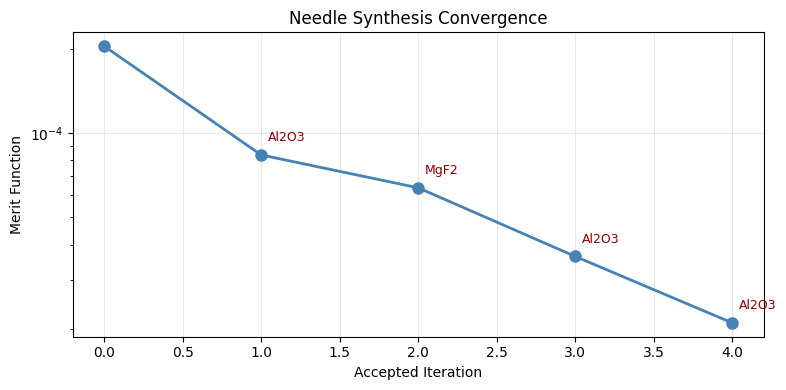

In [7]:
merits = [result.initial_merit] + [h.merit_after for h in result.history]
materials_used = [h.material_name for h in result.history]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(merits)), merits, "o-", color="steelblue", linewidth=2, markersize=8)

# Annotate each insertion with material name
for i, (m, name) in enumerate(zip(merits[1:], materials_used), 1):
    ax.annotate(name, (i, m), textcoords="offset points",
                xytext=(5, 10), fontsize=9, color="darkred")

ax.set_xlabel("Accepted Iteration")
ax.set_ylabel("Merit Function")
ax.set_title("Needle Synthesis Convergence")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
fig.tight_layout();

## 7. Final stack structure

The algorithm autonomously selected which materials to use and determined the optimal layer thicknesses.

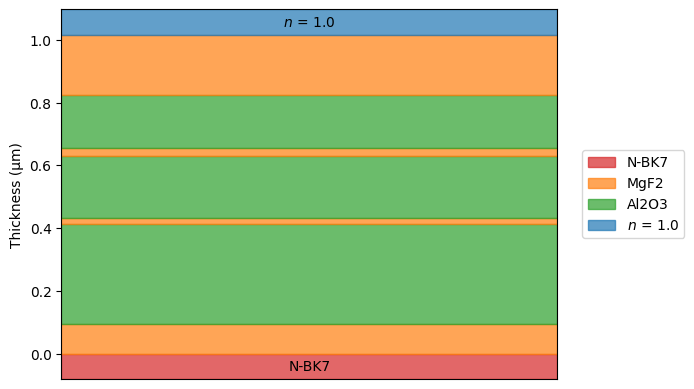

In [8]:
fig, ax = result.stack.plot_structure()

## 8. Before vs. after comparison

The final design meets the stringent R < 1% spec across the entire 420–680 nm band — something impossible with a single-layer coating on N-BK7.

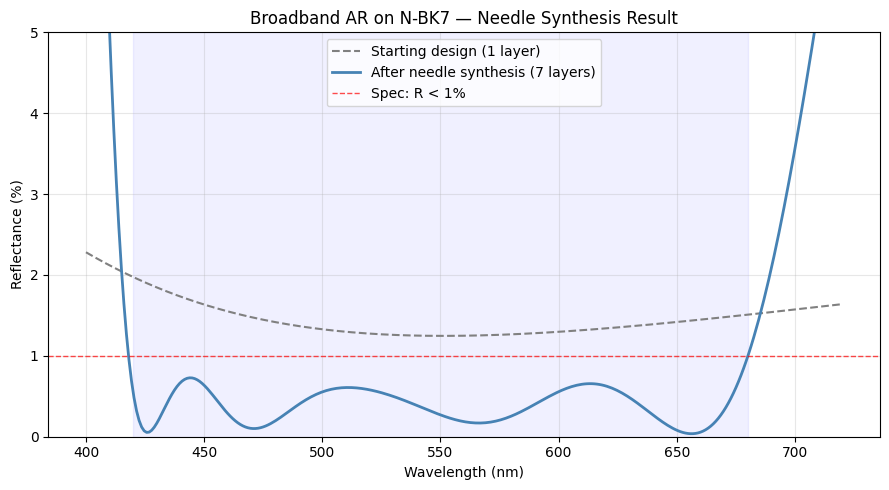

In [9]:
# Rebuild starting design for comparison
stack_initial = ThinFilmStack(incident_material=air, substrate_material=nbk7)
stack_initial.add_layer_nm(mgf2, 100.0, name="MgF2")

wl_eval = np.linspace(400, 720, 300)
R_initial = np.array([ThinFilmOperand.reflectance(stack_initial, wl) for wl in wl_eval])
R_final = np.array([ThinFilmOperand.reflectance(result.stack, wl) for wl in wl_eval])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(wl_eval, R_initial * 100, "--", color="gray",
        linewidth=1.5, label="Starting design (1 layer)")
ax.plot(wl_eval, R_final * 100, "-", color="steelblue",
        linewidth=2, label=f"After needle synthesis ({len(result.stack.layers)} layers)")
ax.axhline(1.0, color="red", linestyle="--", linewidth=1, alpha=0.7, label="Spec: R < 1%")
ax.axvspan(420, 680, alpha=0.06, color="blue")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance (%)")
ax.set_title("Broadband AR on N-BK7 — Needle Synthesis Result")
ax.set_ylim(0, 5)
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout();

---

# Part 2: Dichroic Beamsplitter at 550 nm

A much harder design problem: a **dichroic beamsplitter** that reflects blue/green light (420–540 nm) while transmitting orange/red (560–680 nm) with a sharp transition at 550 nm.

**Specs:**
- Reflection band (420–540 nm): R > 95%
- Transmission band (560–680 nm): T > 95%

This requires many more layers than a simple AR coating and forces the algorithm to build a complex interference structure from scratch.

## 9. Starting design: (HL)^3 quarter-wave stack

We start from a simple 6-layer TiO2/SiO2 quarter-wave stack tuned to 500 nm. This gives some initial reflectance in the blue but is far from meeting spec.

ThinFilmStack Summary
---------------------
Incident:  IdealMaterial
Substrate: N-BK7
Layers:
  1. TiO2 (47.0 nm)
  2. SiO2 (86.0 nm)
  3. TiO2 (47.0 nm)
  4. SiO2 (86.0 nm)
  5. TiO2 (47.0 nm)
  6. SiO2 (86.0 nm)
---------------------
Total Thickness: 399.0 nm


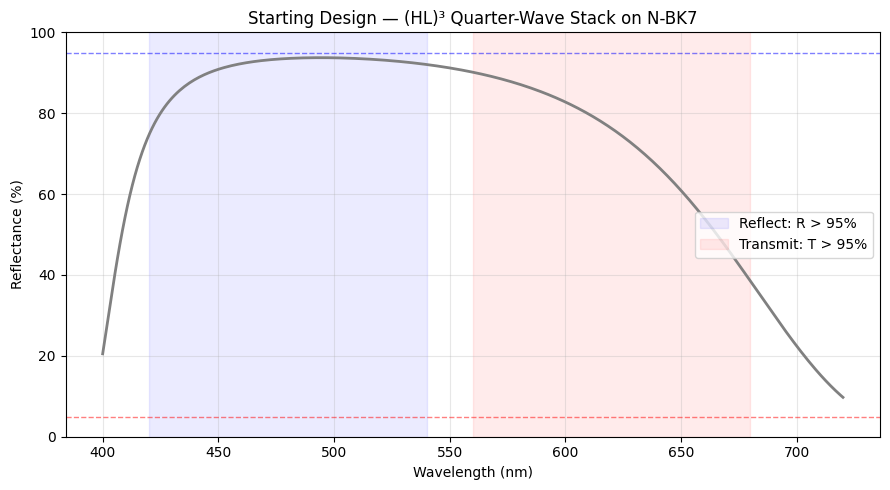

In [10]:
# (HL)^3 quarter-wave stack at 500 nm
# QW optical thickness: n*d = 500/4 = 125 nm
# TiO2 (n~2.65): d = 125/2.65 ~ 47 nm
# SiO2 (n~1.46): d = 125/1.46 ~ 86 nm
stack_d = ThinFilmStack(incident_material=air, substrate_material=nbk7)
for _ in range(3):
    stack_d.add_layer_nm(tio2, 47.0, name="TiO2")
    stack_d.add_layer_nm(sio2, 86.0, name="SiO2")
print(stack_d)

# Plot starting performance
wl_plot = np.linspace(400, 720, 300)
R_start_d = np.array([ThinFilmOperand.reflectance(stack_d, wl) for wl in wl_plot])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(wl_plot, R_start_d * 100, "-", color="gray", linewidth=2)
ax.axvspan(420, 540, alpha=0.08, color="blue", label="Reflect: R > 95%")
ax.axvspan(560, 680, alpha=0.08, color="red", label="Transmit: T > 95%")
ax.axhline(95, color="blue", linestyle="--", linewidth=1, alpha=0.5)
ax.axhline(5, color="red", linestyle="--", linewidth=1, alpha=0.5)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance (%)")
ax.set_title("Starting Design — (HL)³ Quarter-Wave Stack on N-BK7")
ax.set_ylim(0, 100)
ax.legend(loc="center right")
ax.grid(True, alpha=0.3)
fig.tight_layout();

## 10. Run needle synthesis for the dichroic

In [11]:
ns_d = NeedleSynthesis(
    stack=stack_d,
    candidate_materials=[sio2, tio2, mgf2, al2o3],
    needle_thickness_nm=1.0,
    min_thickness_nm=2.0,
    max_iterations=8,
    num_positions_per_layer=3,
    optimizer_max_iter=80,
)

# Reflection band: R → 1 for 420-540 nm
wl_reflect = np.linspace(420, 540, 10).tolist()
ns_d.add_spectral_target("R", wl_reflect, "equal", 1.0)

# Transmission band: R → 0 for 560-680 nm
wl_transmit = np.linspace(560, 680, 10).tolist()
ns_d.add_spectral_target("R", wl_transmit, "equal", 0.0)

result_d = ns_d.run(verbose=True)

Initial merit after refinement: 6.230789e-02


Iteration 0: inserted MgF2 (217.0 nm), layers=6, merit = 5.605842e-02


Iteration 1: inserted TiO2 (345.1 nm), layers=8, merit = 3.244355e-02


Iteration 2: inserted MgF2 (223.8 nm), layers=10, merit = 6.186665e-03


Iteration 3: TiO2 rejected (merit 6.884094e-03 >= 6.186665e-03)


Iteration 4: inserted Al2O3 (172.9 nm), layers=12, merit = 4.869057e-03


Iteration 5: inserted TiO2 (324.8 nm), layers=14, merit = 3.838372e-03


Iteration 6: inserted MgF2 (220.3 nm), layers=16, merit = 1.663441e-03


Iteration 7: inserted TiO2 (358.8 nm), layers=18, merit = 1.258771e-03


## 11. Dichroic results

In [12]:
print(f"Success:       {result_d.success}")
print(f"Layers added:  {result_d.num_layers_added}")
print(f"Initial merit: {result_d.initial_merit:.6e}")
print(f"Final merit:   {result_d.final_merit:.6e}")
print(f"Improvement:   {(1 - result_d.final_merit / result_d.initial_merit) * 100:.1f}%")
print(f"\nFinal stack ({len(result_d.stack.layers)} layers):")
print(result_d.stack)

# Check against specs
wl_r = np.linspace(420, 540, 50)
wl_t = np.linspace(560, 680, 50)
R_reflect = np.array([ThinFilmOperand.reflectance(result_d.stack, wl) for wl in wl_r])
R_transmit = np.array([ThinFilmOperand.reflectance(result_d.stack, wl) for wl in wl_t])
print(f"\nReflection band (420-540 nm):")
print(f"  Average R: {np.mean(R_reflect)*100:.1f}%")
print(f"  Min R:     {np.min(R_reflect)*100:.1f}%")
print(f"\nTransmission band (560-680 nm):")
print(f"  Average T: {(1-np.mean(R_transmit))*100:.1f}%")
print(f"  Min T:     {(1-np.max(R_transmit))*100:.1f}%")

Success:       True
Layers added:  7
Initial merit: 6.230789e-02
Final merit:   1.258771e-03
Improvement:   98.0%

Final stack (18 layers):
ThinFilmStack Summary
---------------------
Incident:  IdealMaterial
Substrate: N-BK7
Layers:
  1. TiO2 (26.6 nm)
  2. SiO2 (69.2 nm)
  3. TiO2 (42.3 nm)
  4. SiO2 (77.4 nm)
  5. TiO2 (37.7 nm)
  6. MgF2 (80.1 nm)
  7. TiO2 (131.0 nm)
  8. MgF2 (154.0 nm)
  9. TiO2 (133.6 nm)
  10. MgF2 (269.0 nm)
  11. TiO2 (140.4 nm)
  12. MgF2 (207.3 nm)
  13. TiO2 (114.3 nm)
  14. MgF2 (77.5 nm)
  15. Al2O3 (119.8 nm)
  16. TiO2 (369.2 nm)
  17. Al2O3 (73.7 nm)
  18. MgF2 (110.0 nm)
---------------------
Total Thickness: 2233.2 nm



Reflection band (420-540 nm):
  Average R: 96.7%
  Min R:     53.3%

Transmission band (560-680 nm):
  Average T: 98.5%
  Min T:     95.9%


## 12. Dichroic convergence

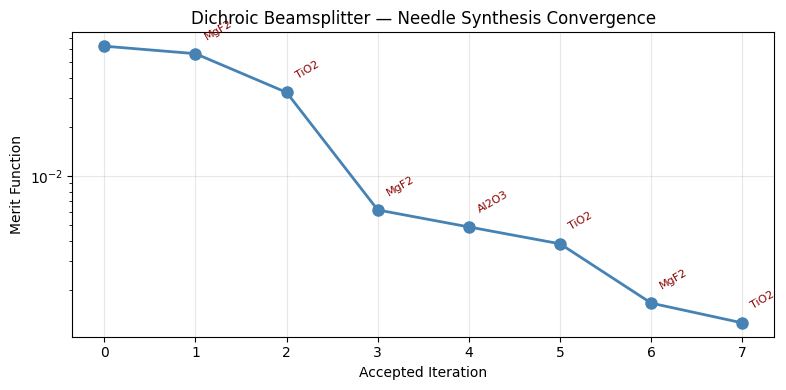

In [13]:
merits_d = [result_d.initial_merit] + [h.merit_after for h in result_d.history]
materials_d = [h.material_name for h in result_d.history]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(merits_d)), merits_d, "o-", color="steelblue", linewidth=2, markersize=8)

for i, (m, name) in enumerate(zip(merits_d[1:], materials_d), 1):
    ax.annotate(name, (i, m), textcoords="offset points",
                xytext=(5, 10), fontsize=8, color="darkred", rotation=30)

ax.set_xlabel("Accepted Iteration")
ax.set_ylabel("Merit Function")
ax.set_title("Dichroic Beamsplitter — Needle Synthesis Convergence")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
fig.tight_layout();

## 13. Stack structure

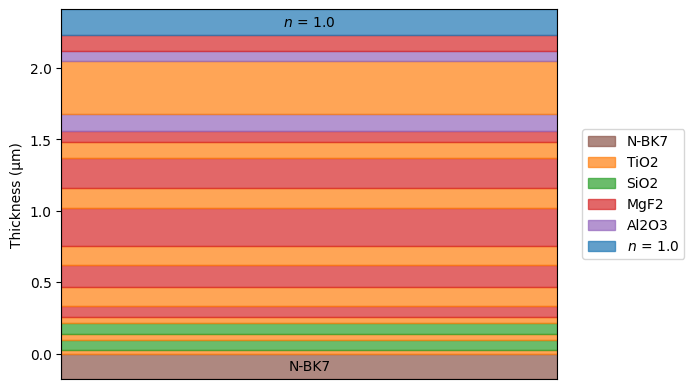

In [14]:
fig, ax = result_d.stack.plot_structure()

## 14. Dichroic spectral performance

The final comparison shows the starting (HL)³ stack vs. the optimized dichroic. The algorithm built a sharp transition edge at 550 nm using all four candidate materials.

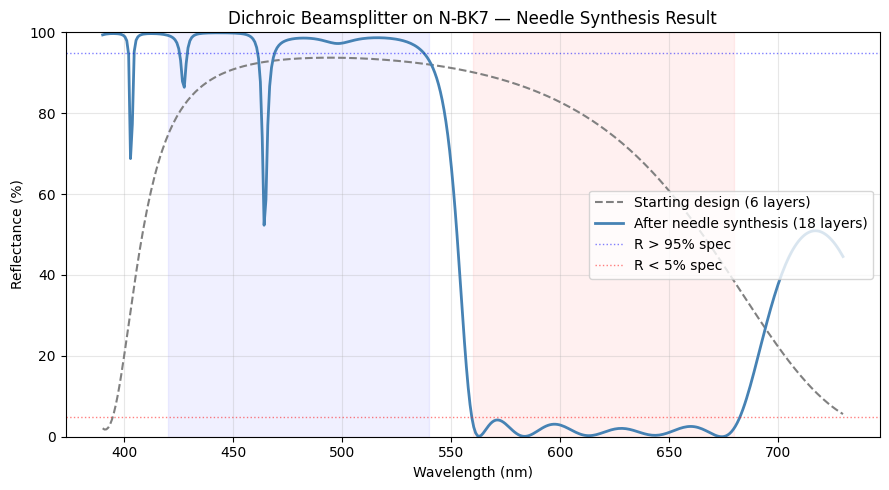

In [15]:
# Rebuild starting design for comparison
stack_d_initial = ThinFilmStack(incident_material=air, substrate_material=nbk7)
for _ in range(3):
    stack_d_initial.add_layer_nm(tio2, 47.0, name="TiO2")
    stack_d_initial.add_layer_nm(sio2, 86.0, name="SiO2")

wl_eval = np.linspace(390, 730, 400)
R_d_initial = np.array([ThinFilmOperand.reflectance(stack_d_initial, wl) for wl in wl_eval])
R_d_final = np.array([ThinFilmOperand.reflectance(result_d.stack, wl) for wl in wl_eval])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(wl_eval, R_d_initial * 100, "--", color="gray",
        linewidth=1.5, label="Starting design (6 layers)")
ax.plot(wl_eval, R_d_final * 100, "-", color="steelblue",
        linewidth=2, label=f"After needle synthesis ({len(result_d.stack.layers)} layers)")
ax.axvspan(420, 540, alpha=0.06, color="blue")
ax.axvspan(560, 680, alpha=0.06, color="red")
ax.axhline(95, color="blue", linestyle=":", linewidth=1, alpha=0.5, label="R > 95% spec")
ax.axhline(5, color="red", linestyle=":", linewidth=1, alpha=0.5, label="R < 5% spec")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance (%)")
ax.set_title("Dichroic Beamsplitter on N-BK7 — Needle Synthesis Result")
ax.set_ylim(0, 100)
ax.legend(loc="center right")
ax.grid(True, alpha=0.3)
fig.tight_layout();